# Ximenez: Model (New)

# Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import sys
sys.path.append('../../local_lib/')
from narrative_model import NarrativeModel

In [2]:
sns.set_theme(style='white')
px_template = 'plotly_white'

# Data

In [3]:
src_id = "ximenez"
n_chunks = 60
CHUNK = pd.read_csv(f"{src_id}-CHUNK-{n_chunks}.csv").set_index('chunk_num')
TFIDF = pd.read_csv(f"{src_id}-TFIDF-{n_chunks}.csv").set_index('chunk_num')

# Model

Text(0.5, 1.0, 'TFIDF SIM euclidean + ward')

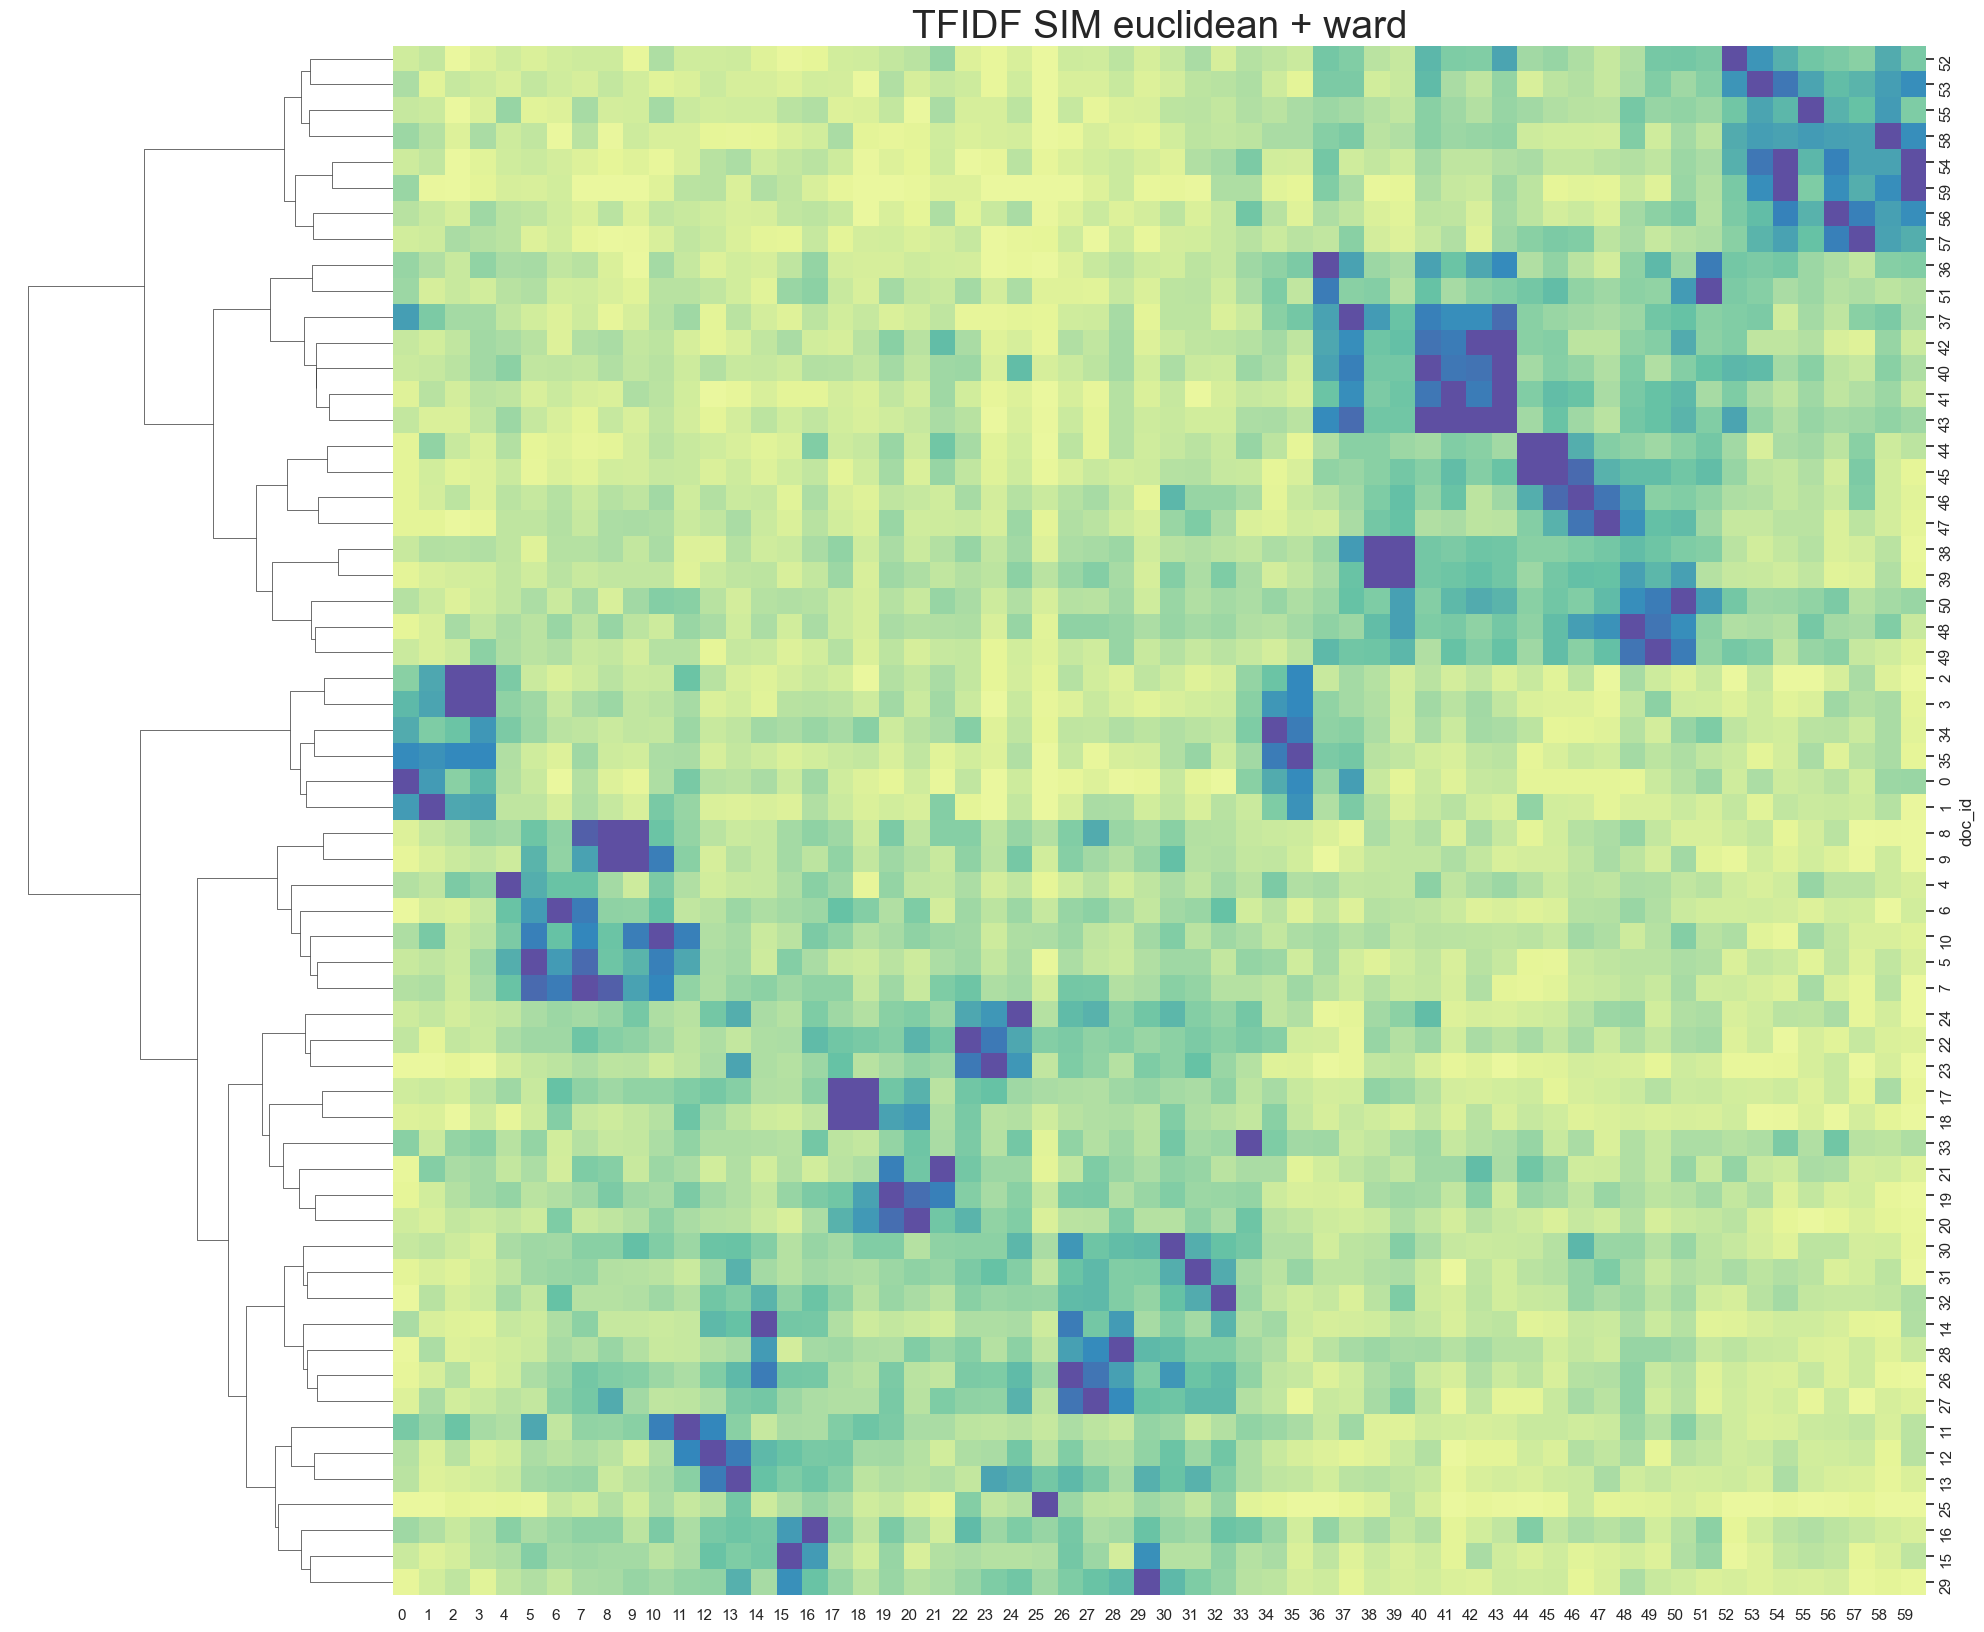

In [136]:
model = NarrativeModel(src_id, CHUNK, TFIDF)
model.use_sim = True
model.compute_tfidf_sim()
model.plot_tfidf_clustermap()
plt.title(f"TFIDF SIM {model.distance_metric} + {model.linkage_method}", fontsize=28)

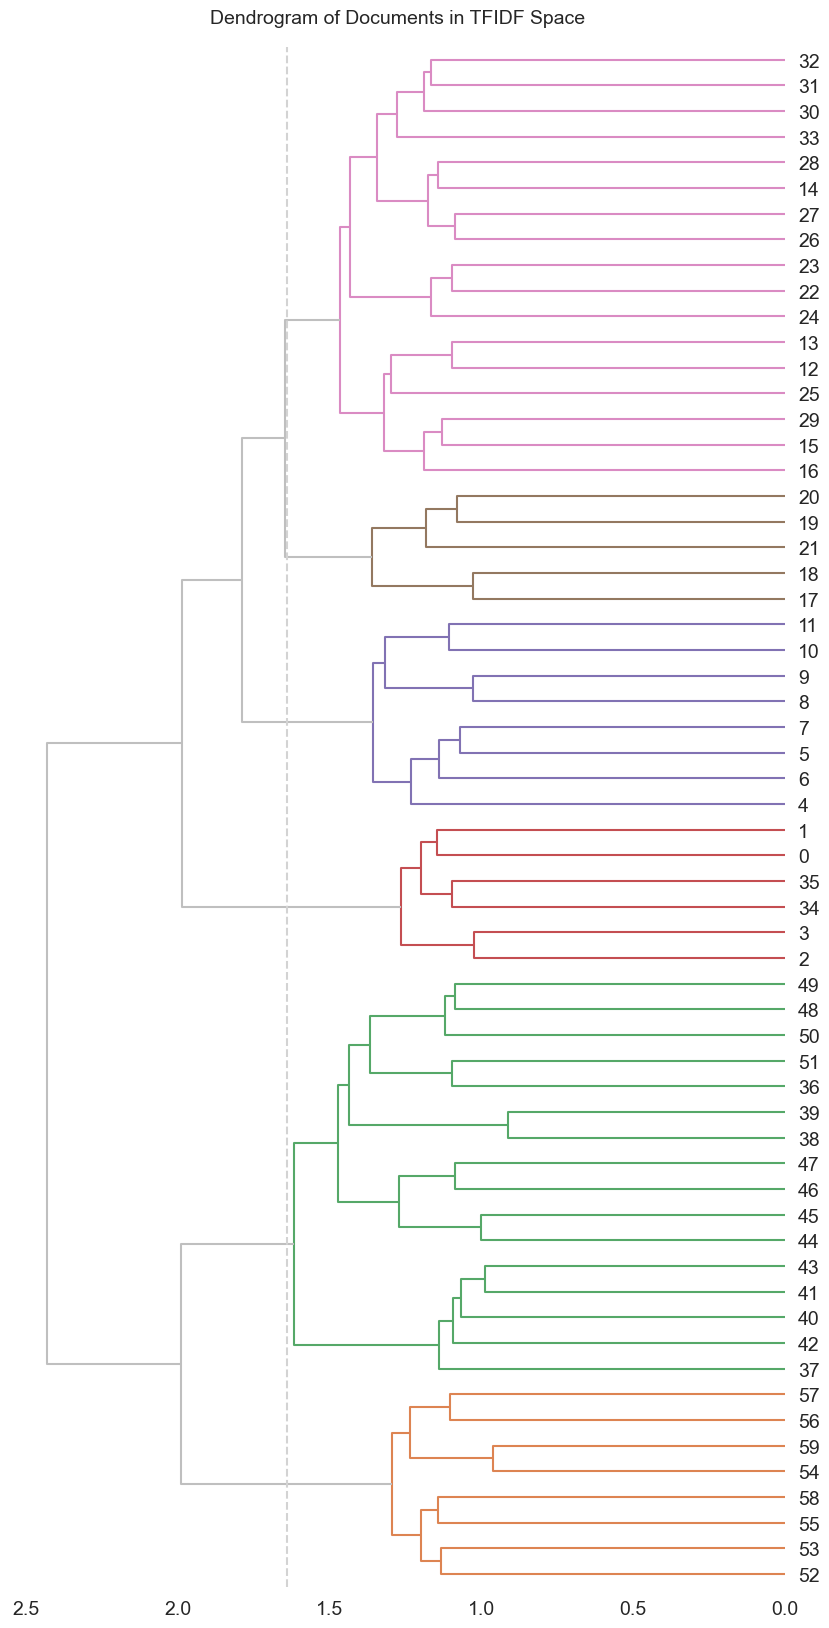

In [40]:
model.use_sim = False
model.distance_metric = 'euclidean'
model.linkage_method = 'ward'
model.hac_color_thresh = 1.64
model.cluster()

In [39]:
model.CLUSTER

,n_chunks,gloss,top_terms
hac_label,,,
7,17,came,"came, xibalba, que, quic, zamahel, vvcub, vholom"
3,9,tohil,"tohil, amac, balam, quitze, acab, aulix, mahuc..."
1,8,ahpop,"ahpop, ahau, quiche, camha, chinamit, ahauarem..."
5,7,zipacna,"zipacna, caquix, qaholab, in, nu, vvcub, huiub"
2,7,chila,"chila, quih, relebal, tamub, balam, vzaquiric,..."
4,6,cah,"cah, alom, qaholom, bit, bitol, tzacol, tzac"
6,6,atit,"atit, batz, catit, chouen, choven, bix, q'iquin"


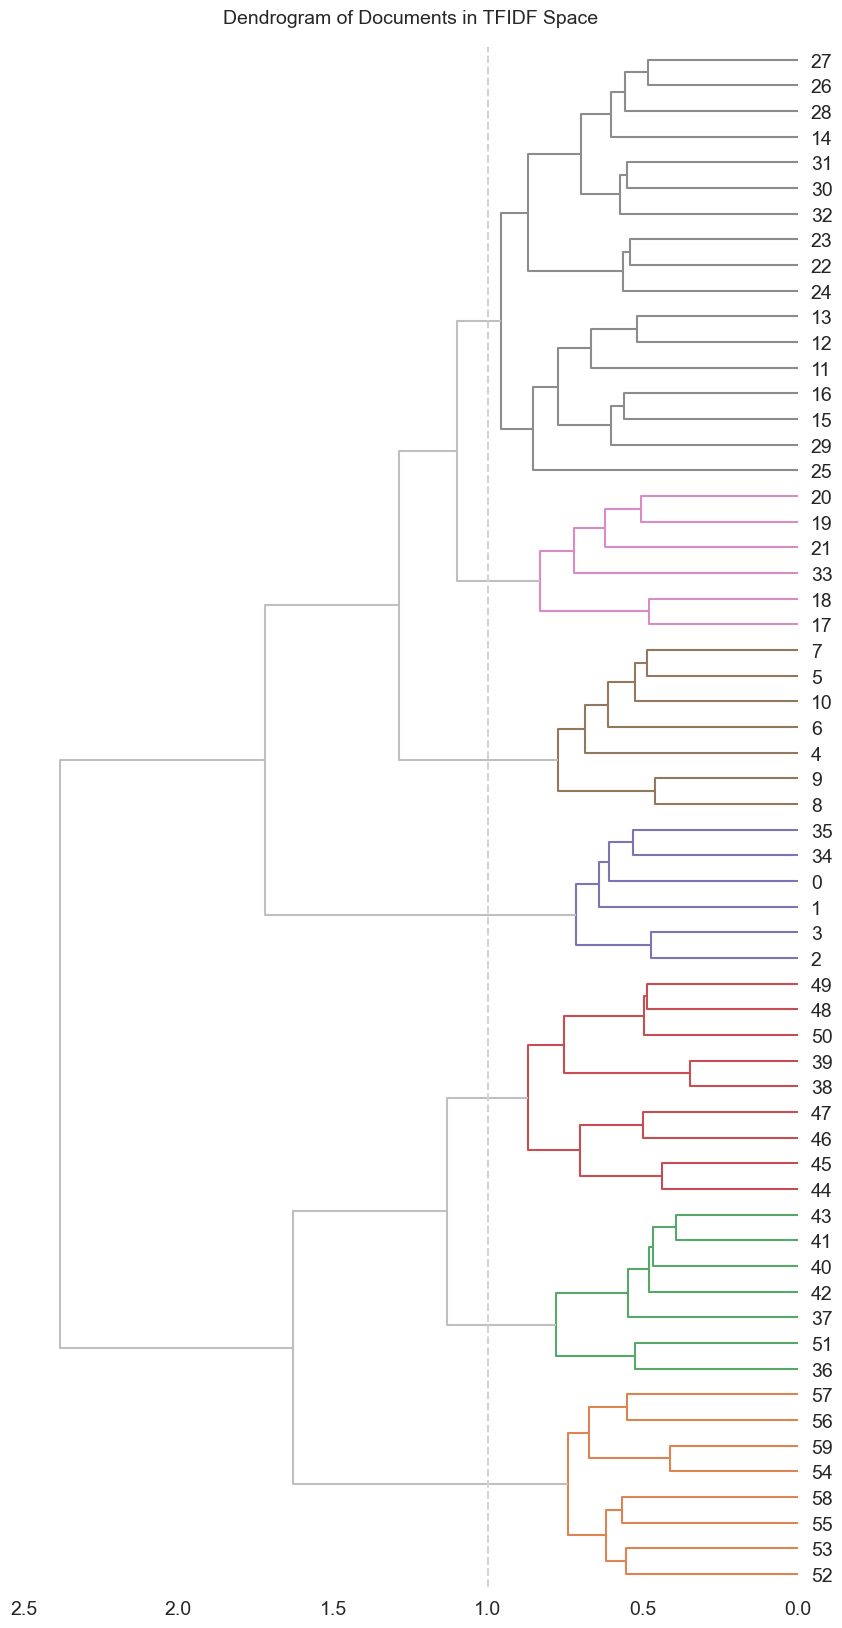

In [37]:
model.use_sim = True
model.hac_color_thresh = 1
model.cluster()

In [138]:
model.CHUNK

,chunk_str,doc_id
chunk_num,,
0,are v xe oher tzih varal quiche vbi varal xchi...,1 2 3 4 5
1,qazlem hupacha ta cha uaxoc ta caquiro puch ap...,5 6 7
2,xeqhauic xeqha chic qui bil quib maui mixutzin...,7 8
3,camul alom camul qaholom nimac nima tziz ah cu...,8 9
4,vach rumal che abah xqhauic ronohel qui quebal...,9 10
5,rib rivxic vpuvac xere cut tocol vi v vach ri ...,10 11 12
6,xbe vqhapa cate cut ta xcupix vla veab rihun h...,12
7,vi nu caubal ri ve ruq vbac nu vach xchicacoh ...,12 13
8,hun nima hul naht xcahic ta xquitac cut ri zip...,13


# Explore PCA

In [41]:
model.CLUSTER

,n_chunks,gloss,top_terms
hac_label,,,
4,17,xibalba,"xibalba, came, quic, que, zamahel, vholom, hun..."
6,16,balam,"balam, tohil, quitze, amac, mahucutah, acab, iqui"
2,8,zipacna,"zipacna, caquix, qaholab, in, nu, vvcub, cahoc"
5,8,ahpop,"ahpop, ahau, quiche, camha, chinamit, ahauarem..."
1,6,cah,"cah, alom, qaholom, bit, bitol, tzacol, tzac"
3,5,atit,"atit, batz, chouen, catit, choven, bix, q'iquin"


In [87]:
label_col = 'hac_label'
model.compute_pca()
X0 = model.CHUNK.join(model.PCAX).join(model.CLUSTER, on=label_col)
X0['viz_label'] = X0.apply(lambda x: f"C{x.hac_label} {x.gloss}", axis=1)
# X0.head()

In [88]:
X0.value_counts(['hac_label','gloss']).unstack(fill_value=0).style.background_gradient(axis=None)

gloss,ahpop,atit,balam,cah,xibalba,zipacna
hac_label,,,,,,
1,0,0,0,6,0,0
2,0,0,0,0,0,8
3,0,5,0,0,0,0
4,0,0,0,0,17,0
5,8,0,0,0,0,0
6,0,0,16,0,0,0


In [89]:
def plot_pca(x, y):
    px.scatter(X0, x, y,
        text=X0.index,
        height=450, width=850,
        color='viz_label',
        size=[1 for i in range(len(X0))],
        template=px_template,
    ).show()

In [90]:
plot_pca(0, 1)

In [55]:
plot_pca(1, 2)

In [91]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss',
           template=px_template,
           height=400, width=800,
           title=f'PC {comp_id}').show()

for i in range(model.n_pca_comps):
    comp_box(i)

In [98]:
X1 = X0.groupby('viz_label')[[0,1,2,3,4,]].mean()
X1.style.background_gradient(axis=None, cmap="Spectral")

,0,1,2,3,4
viz_label,,,,,
C1 cah,0.043373,-0.350073,-0.315578,-0.171090,-0.111825
C2 zipacna,-0.191534,-0.080292,-0.103372,0.350088,-0.020676
C3 atit,-0.179998,0.034206,-0.040894,-0.064442,0.331624
C4 xibalba,-0.230425,0.040331,0.109596,-0.109355,-0.028543
C5 ahpop,0.296352,-0.183739,0.319839,0.059480,0.018096
C6 balam,0.232403,0.209752,-0.093558,-0.004297,-0.030082


In [99]:
X1[0].sort_values()

viz_label
C4 xibalba   -0.230425
C2 zipacna   -0.191534
C3 atit      -0.179998
C1 cah        0.043373
C6 balam      0.232403
C5 ahpop      0.296352
Name: 0, dtype: float64

In [100]:
X1[1].sort_values()

viz_label
C1 cah       -0.350073
C5 ahpop     -0.183739
C2 zipacna   -0.080292
C3 atit       0.034206
C4 xibalba    0.040331
C6 balam      0.209752
Name: 1, dtype: float64

In [101]:
X1[2].sort_values()

viz_label
C1 cah       -0.315578
C2 zipacna   -0.103372
C6 balam     -0.093558
C3 atit      -0.040894
C4 xibalba    0.109596
C5 ahpop      0.319839
Name: 2, dtype: float64

In [102]:
X1[3].sort_values()

viz_label
C1 cah       -0.171090
C4 xibalba   -0.109355
C3 atit      -0.064442
C6 balam     -0.004297
C5 ahpop      0.059480
C2 zipacna    0.350088
Name: 3, dtype: float64

In [ ]:
X1[4].sort_values().

viz_label
C1 cah       -0.111825
C6 balam     -0.030082
C4 xibalba   -0.028543
C2 zipacna   -0.020676
C5 ahpop      0.018096
C3 atit       0.331624
Name: 4, dtype: float64

In [107]:
X1

,0,1,2,3,4
viz_label,,,,,
C1 cah,0.043373,-0.350073,-0.315578,-0.171090,-0.111825
C2 zipacna,-0.191534,-0.080292,-0.103372,0.350088,-0.020676
C3 atit,-0.179998,0.034206,-0.040894,-0.064442,0.331624
C4 xibalba,-0.230425,0.040331,0.109596,-0.109355,-0.028543
C5 ahpop,0.296352,-0.183739,0.319839,0.059480,0.018096
C6 balam,0.232403,0.209752,-0.093558,-0.004297,-0.030082


In [118]:
px.scatter(X1.reset_index(),
           x=0,
           y=1,
           color='viz_label',
           text='viz_label',
           template=px_template,
           height=800, width=800,
           size=[1 for i in range(len(X1))]
).show()
